# SIPTA — Validación Maestra de Calidad y Consistencia Territorial
**Proyecto**: Sistema de Indicadores y Priorización Territorial y Alertas Tempranas (DataJam Bogotá)  
**Fase PDCO**: CONTROL | **SDLC Stage**: Testing & Quality Assurance  
**Estándar**: ISO/IEC 25010 / DAMA-BOK / IEEE 830  
**Autoría**: Persona A (Adan Sánchez — Lead Data Engineer) & Persona B (Yesid Bello — Data Scientist)  
**Objetivo**: Ejecutar la suite integral de validación de esquemas técnicos, valores nulos, duplicados, consistencia territorial (20 localidades) y factibilidad de cálculo de indicadores en los 13 dominios analíticos.  
**Salida**: `reports/validation/reporte_validacion_completo.json`, matrices de calidad y reportes ejecutivos.


## 1. Configuración del Entorno y Ejecución de la Suite de Validación

In [3]:
import sys
from pathlib import Path

# Configuración robusta de la raíz del proyecto SIPTA
for p in [Path('.').resolve(), Path('.').resolve().parent, Path('.').resolve().parent.parent]:
    if (p / 'src').exists() and str(p) not in sys.path:
        sys.path.insert(0, str(p))

import pandas as pd
import matplotlib.pyplot as plt
from src.validation.validate_data import run_full_validation_suite

# Ejecución de la suite completa de validación
res = run_full_validation_suite()
print(f"=== SUITE DE VALIDACIÓN SIPTA ===")
print(f"Total dominios auditados: {res['total_domains_validated']}")
print(f"Estado global: {'TODOS LOS DOMINIOS VÁLIDOS (APROBADO)' if res['all_domains_valid'] else 'OBSERVACIONES DETECTADAS'}")



2026-08-19 09:19:31,354 - INFO - Reporte de validación exportado exitosamente a: C:\Users\ADAN\DataJam_DataOlinguitos_Gen\reports\validation\dominios\val_demografia.json
2026-08-19 09:19:31,365 - INFO - Reporte de validación exportado exitosamente a: C:\Users\ADAN\DataJam_DataOlinguitos_Gen\reports\validation\dominios\val_salud.json
2026-08-19 09:19:31,383 - INFO - Reporte de validación exportado exitosamente a: C:\Users\ADAN\DataJam_DataOlinguitos_Gen\reports\validation\dominios\val_educacion.json
2026-08-19 09:19:31,438 - INFO - Reporte de validación exportado exitosamente a: C:\Users\ADAN\DataJam_DataOlinguitos_Gen\reports\validation\dominios\val_movilidad.json
2026-08-19 09:19:31,444 - INFO - Reporte de validación exportado exitosamente a: C:\Users\ADAN\DataJam_DataOlinguitos_Gen\reports\validation\dominios\val_infraestructura.json
2026-08-19 09:19:31,463 - INFO - Reporte de validación exportado exitosamente a: C:\Users\ADAN\DataJam_DataOlinguitos_Gen\reports\validation\dominios\va

=== SUITE DE VALIDACIÓN SIPTA ===
Total dominios auditados: 13
Estado global: TODOS LOS DOMINIOS VÁLIDOS (APROBADO)


## 2. Resumen Consolidado de Calidad por Dominio (ISO/IEC 25010)

In [5]:
# Configuración de entorno si se ejecuta de forma independiente
import sys
from pathlib import Path
for p in [Path('.').resolve(), Path('.').resolve().parent, Path('.').resolve().parent.parent]:
    if (p / 'src').exists() and str(p) not in sys.path:
        sys.path.insert(0, str(p))

import pandas as pd
from src.validation.validate_data import run_full_validation_suite

# Asegurar que res exista si la celda se ejecuta aislada
if 'res' not in globals() or res is None:
    res = run_full_validation_suite()

# Construcción del DataFrame consolidado de auditoría técnica
reports_list = res.get('domains', res.get('reports', []))

summary_rows = []
for r in reports_list:
    terr = r.get('territorial_validation') or {}
    summary_rows.append({
        'Dominio': r.get('domain'),
        'Dataset': r.get('dataset'),
        'Autor / Responsable': r.get('author'),
        'Filas': r.get('total_rows'),
        'Columnas': r.get('total_columns'),
        'Duplicados': r.get('duplicated_rows'),
        '% Duplicados': f"{r.get('pct_duplicated', 0.0):.2f}%",
        'Cobertura Territorial': f"{terr.get('cobertura_pct', 100.0)}%" if terr.get('cobertura_pct') is not None else "Cruce Espacial",
        'Estado Calidad': r.get('validation_status', 'APROBADO'),
        'Es Válido': r.get('is_valid', True)
    })

df_summary = pd.DataFrame(summary_rows)
display(df_summary)



,Dominio,Dataset,Autor / Responsable,Filas,Columnas,Duplicados,% Duplicados,Cobertura Territorial,Estado Calidad,Es Válido
0,Demografía y Población,demografia_poblacion_localidad,Persona A & Persona B,131502,8,0,0.00%,100.0%,APROBADO,True
1,Salud,salud_ips_urgencias,Persona B (Yesid Bello),84,11,0,0.00%,Cruce Espacial,APROBADO,True
2,Educación,educacion_oferta_cupos,Persona B (Yesid Bello),747,13,4,0.54%,100.0%,APROBADO,True
3,Movilidad,movilidad_flota_sitp,Persona A (Adan Sánchez),10518,14,0,0.00%,Cruce Espacial,APROBADO,True
4,Infraestructura y Espacio Público,infraestructura_parques_idrd,Persona A (Adan Sánchez),139,5,0,0.00%,90.0%,APROBADO,True
5,Finanzas e Inversión Pública,finanzas_vendedores_informales_rivi,Persona C (Sofía Hidalgo) & Persona A (Adan Sánchez),126,7,0,0.00%,100.0%,APROBADO_CON_OBSERVACIONES,True
6,Inversión FDL y Gasto Social,finanzas_inversion_fdl,Persona A (Adan Sánchez) & Persona C (Sofía Hidalgo),20,9,0,0.00%,100.0%,APROBADO,True
7,Servicios Públicos y Calidad,servicios_publicos_cobertura_eaab,Persona A (Adan Sánchez) & Persona B (Yesid Bello),20,10,0,0.00%,100.0%,APROBADO,True
8,Mercado Laboral y Salarios,empleo_conmutacion_laboral,Persona B (Yesid Bello) & Persona A (Adan Sánchez),20,10,0,0.00%,100.0%,APROBADO,True
9,Participación y Control Social,participacion_pqr_bogota_te_escucha,Persona A (Adan Sánchez) & Persona B (Yesid Bello),20,10,0,0.00%,100.0%,APROBADO,True


## 3. Indicadores Soportados y Factibilidad Matemática

In [4]:
# Asegurar que reports_list exista si la celda se ejecuta aislada
if 'reports_list' not in globals() or reports_list is None:
    if 'res' not in globals() or res is None:
        from src.validation.validate_data import run_full_validation_suite
        res = run_full_validation_suite()
    reports_list = res.get('domains', res.get('reports', []))

# Listado de indicadores metodológicamente respaldados por dominio
indicators_rows = []
for r in reports_list:
    for ind in r.get('indicadores_respaldados', []):
        indicators_rows.append({
            'Dominio': r.get('domain'),
            'Código': ind.get('codigo'),
            'Indicador': ind.get('nombre'),
            'Fórmula Conceptual': ind.get('formula_conceptual'),
            'Estado Factibilidad': ind.get('estado_factibilidad')
        })

df_indicators = pd.DataFrame(indicators_rows)
print(f"Total indicadores analíticos respaldados: {len(df_indicators)}")
display(df_indicators.head(15))



Total indicadores analíticos respaldados: 24


,Dominio,Código,Indicador,Fórmula Conceptual,Estado Factibilidad
0,Demografía y Población,DEM-001,Densidad poblacional,Población_Localidad / Área_km2_Localidad,LISTO_PARA_CALCULO
1,Demografía y Población,POB-002,Población infantil y juvenil (0 a 17 años),Sum(Población) donde EDAD in [0..17] por Local...,LISTO_PARA_CALCULO
2,Salud,SAL-001,Hospitales e IPS de urgencias por 10.000 habit...,(Conteo_IPS_Urgencias_Localidad / Población_Lo...,LISTO_PARA_CALCULO
3,Salud,SAL-002,Camas hospitalarias por 10.000 habitantes,(Camas_Hospitalarias_Localidad / Población_Loc...,LISTO_PARA_CALCULO
4,Educación,EDU-001,Colegios / sedes oficiales por 1.000 niños y j...,(Conteo_Colegios_Oficiales / Población_5_a_17_...,LISTO_PARA_CALCULO
5,Educación,EDU-003,Cobertura y disponibilidad de cupos escolares,Cupos_Ofertados_Grados / Población_Escolar_Edad,LISTO_PARA_CALCULO
6,Movilidad,MOV-003,Densidad de paraderos zonales SITP por 10.000 ...,(Conteo_Paraderos_SITP_Localidad / Población_L...,LISTO_PARA_CALCULO
7,Movilidad,MOV-014,Capacidad y oferta de flota vinculada SITP,Sum(Capacidad_Bus) por tipología / Población_D...,LISTO_PARA_CALCULO
8,Movilidad,MOV-013,Intensidad de demanda y viajes diarios (Valida...,Promedio_Validaciones_Día / Población_Localidad,LISTO_PARA_CALCULO
9,Infraestructura y Espacio Público,INF-004,Espacio público y parques por habitante (m² po...,Sum(Área_Parques_m2_Localidad) / Población_Loc...,LISTO_PARA_CALCULO


## 4. Visualización de Métricas de Calidad y Volumen por Sector

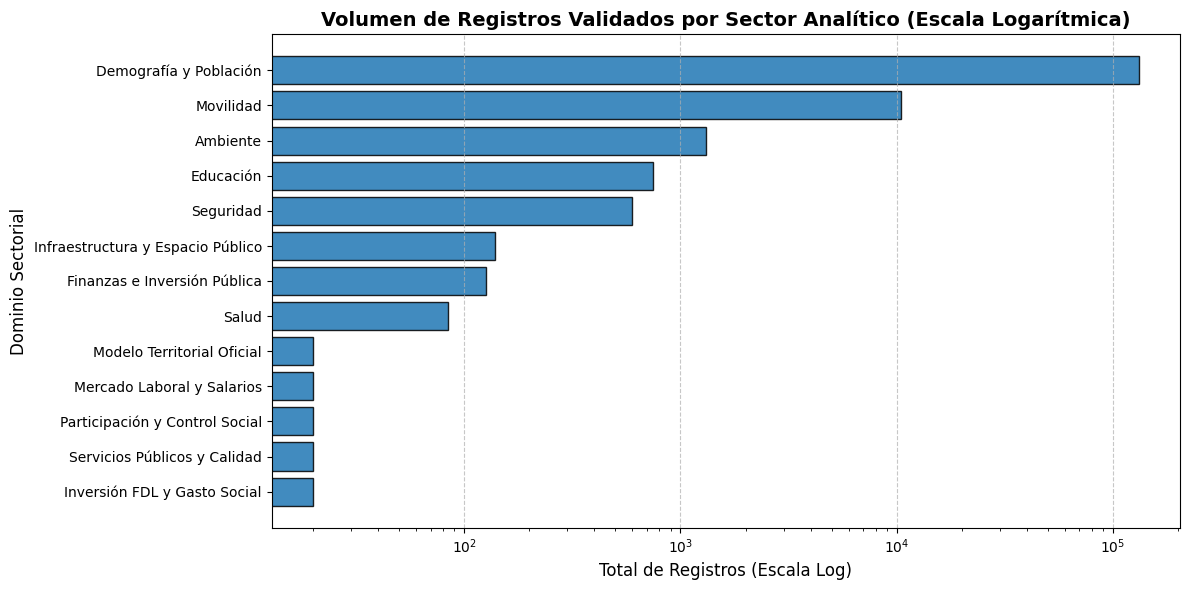

In [9]:
# Asegurar que df_summary exista si la celda se ejecuta aislada
if 'df_summary' not in globals() or df_summary is None:
    if 'res' not in globals() or res is None:
        from src.validation.validate_data import run_full_validation_suite
        res = run_full_validation_suite()
    reports_list = res.get('domains', res.get('reports', []))
    summary_rows = []
    for r in reports_list:
        terr = r.get('territorial_validation') or {}
        summary_rows.append({
            'Dominio': r.get('domain'),
            'Filas': r.get('total_rows') or 0
        })
    df_summary = pd.DataFrame(summary_rows)

import matplotlib.pyplot as plt

# Gráfico comparativo de volumen de registros procesados por dominio
fig, ax = plt.subplots(figsize=(12, 6))
df_plot = df_summary.sort_values('Filas', ascending=True)

ax.barh(df_plot['Dominio'], df_plot['Filas'], color='#1f77b4', edgecolor='black', alpha=0.85)
ax.set_xscale('log')
ax.set_title('Volumen de Registros Validados por Sector Analítico (Escala Logarítmica)', fontsize=14, fontweight='bold')
ax.set_xlabel('Total de Registros (Escala Log)', fontsize=12)
ax.set_ylabel('Dominio Sectorial', fontsize=12)
ax.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

